In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('./Downloads/games.csv')



df.columns = ['Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'Discount', 'DLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']

In [3]:
inutiles = ["About the game", "Reviews", "Website", "Support url", "Support email", 
            "Metacritic url", "Notes", "Score rank", "Movies", "Header image", "Screenshots"]
df = df.drop(columns=inutiles)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Name                        122610 non-null  object 
 1   Release date                122611 non-null  object 
 2   Estimated owners            122611 non-null  object 
 3   Peak CCU                    122611 non-null  int64  
 4   Required age                122611 non-null  int64  
 5   Price                       122611 non-null  float64
 6   Discount                    122611 non-null  int64  
 7   DLC count                   122611 non-null  int64  
 8   Supported languages         122611 non-null  object 
 9   Full audio languages        122611 non-null  object 
 10  Windows                     122611 non-null  bool   
 11  Mac                         122611 non-null  bool   
 12  Linux                       122611 non-null  bool   
 13  Metacritic s

In [4]:
import re

def count_languages(row):
    langs = set()
    for col in ["Supported languages", "Full audio languages"]:
        val = str(row[col])
        # Extraire le contenu entre [ et ]
        matches = re.findall(r'\[([^\]]*)\]', val)
        for match in matches:
            if match.strip():
                # Compter les éléments par les virgules
                items = [x.strip().strip("'") for x in match.split(',')]
                langs.update(items)
    return len(langs)

df["Language Count"] = df.apply(count_languages, axis=1)

In [23]:
df = df.loc[
    df.groupby(['Name', 'Developers', 'Publishers'])['Peak CCU'].idxmax()
]

# Grouping release years

In [50]:
years = pd.DatetimeIndex(pd.to_datetime(df["Release date"])).year
years

Index([2023, 2016, 2020, 2018, 2018, 2024, 2025, 2020, 2017, 2024,
       ...
       2022, 2024, 2022, 2019, 2025, 2017, 2018, 2025, 2018, 2023],
      dtype='int32', name='Release date', length=113420)

In [64]:
years = pd.DatetimeIndex(pd.to_datetime(df["Release date"])).year
df["Year of Release"] = years
df["Year of Release"].value_counts()

Year of Release
2025    21630
2024    17962
2023    13221
2022    11288
2021    10315
2020     8703
2018     7356
2019     7184
2017     5855
2016     4086
2015     2452
2014     1503
2013      433
2012      316
2009      274
2011      242
2010      217
2008      130
2026       84
2007       81
2006       61
2005        7
2004        5
2001        4
2003        3
1997        2
2000        2
1999        2
1998        1
2002        1
Name: count, dtype: int64

In [65]:
df.loc[df["Year of Release"] <= 2013, "Year of Release"] = 2013
df.loc[df["Year of Release"] == 2026, "Year of Release"] = 2025

In [66]:
df["Year of Release"].value_counts()

Year of Release
2025    21714
2024    17962
2023    13221
2022    11288
2021    10315
2020     8703
2018     7356
2019     7184
2017     5855
2016     4086
2015     2452
2013     1781
2014     1503
Name: count, dtype: int64

In [67]:
df["Year of Release"] = df["Year of Release"].astype('object')

In [69]:
df = df.drop(columns="Release date")

# Création de la colonne TagGenre

In [70]:
def merge_and_clean(row):
    tags = str(row['Tags']).split(',') if pd.notna(row['Tags']) else[]
    genres = str(row['Genres']).split(',') if pd.notna(row['Genres']) else[] 
    
    tous_les_mots =[mot.strip() for mot in (tags + genres) if mot.strip()]
    mots_uniques = set(tous_les_mots)
    return ','.join(mots_uniques)
    
df2 = df.copy(deep = True)
combined_series = df2.apply(merge_and_clean, axis=1)
combined_dummies = combined_series.str.get_dummies(sep=',').astype(bool)
combined_dummies.columns =[f"TagGenre_{c}" for c in combined_dummies.columns]
df2 = pd.concat([df2, combined_dummies], axis=1)
print(df2.head())

                                                 Name Estimated owners  \
2556940                                 ! Shakabula *        0 - 20000   
449940   ! That Bastard Is Trying To Steal Our Gold !   50000 - 100000   
1287250                               ! Wild Russia !        0 - 20000   
866510                                       !AnyWay!  100000 - 200000   
870990                                     !LABrpgUP!    20000 - 50000   

         Peak CCU  Required age  Price  Discount  DLC count  \
2556940         0             0  14.99         0          0   
449940          0             0   2.99         0          0   
1287250         0             0  19.99         0          0   
866510          2             0   1.79        10         39   
870990          0             0   0.99         0          0   

                                       Supported languages  \
2556940                                        ['English']   
449940                                         ['Eng

In [71]:
Optionels = ["Developers", "Publishers"]
df2 = df2.drop(columns=Optionels)
df2.info(verbose=all)

<class 'pandas.core.frame.DataFrame'>
Index: 113420 entries, 2556940 to 2639280
Data columns (total 479 columns):
 #    Column                                      Dtype  
---   ------                                      -----  
 0    Name                                        object 
 1    Estimated owners                            object 
 2    Peak CCU                                    int64  
 3    Required age                                int64  
 4    Price                                       float64
 5    Discount                                    int64  
 6    DLC count                                   int64  
 7    Supported languages                         object 
 8    Full audio languages                        object 
 9    Windows                                     bool   
 10   Mac                                         bool   
 11   Linux                                       bool   
 12   Metacritic score                            int64  
 13   User score

In [72]:
Categories_dummies = df2['Categories'].str.get_dummies(sep=',').astype(bool)
Categories_dummies.columns = [f"Categories_{c.strip()}" for c in Categories_dummies.columns] # merci gemini
df2 = pd.concat([df2, Categories_dummies], axis=1)
print(df2.head())

                                                 Name Estimated owners  \
2556940                                 ! Shakabula *        0 - 20000   
449940   ! That Bastard Is Trying To Steal Our Gold !   50000 - 100000   
1287250                               ! Wild Russia !        0 - 20000   
866510                                       !AnyWay!  100000 - 200000   
870990                                     !LABrpgUP!    20000 - 50000   

         Peak CCU  Required age  Price  Discount  DLC count  \
2556940         0             0  14.99         0          0   
449940          0             0   2.99         0          0   
1287250         0             0  19.99         0          0   
866510          2             0   1.79        10         39   
870990          0             0   0.99         0          0   

                                       Supported languages  \
2556940                                        ['English']   
449940                                         ['Eng

In [73]:
df3 = df2.copy(deep = True)
df3["Positive"] = np.log2(df3["Positive"] + 1)
df3["Negative"] = np.log2(df3["Negative"] + 1)
df3["Recommendations"] = np.log2(df3["Recommendations"] + 1)
df3["Average playtime forever"] = np.log2(df3["Average playtime forever"] + 1)
df3["Median playtime forever"] = np.log2(df3["Median playtime forever"] + 1)

# ACP

In [74]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [75]:
data_pca = df3.select_dtypes(include=["number", "int64"])
scaler = StandardScaler()
scaled_df3 = scaler.fit_transform(data_pca)
pca = PCA()
pca_df3 = pca.fit_transform(scaled_df3) 
explained_variance = pca.explained_variance_ratio_

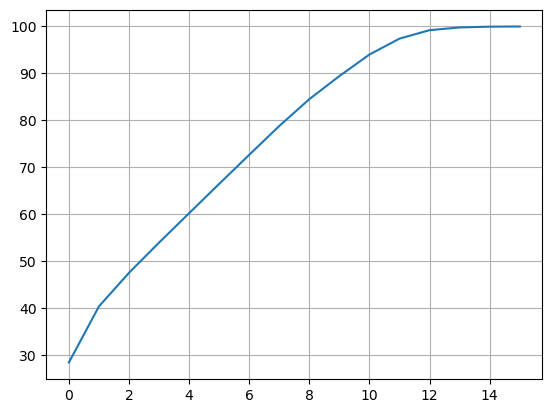

In [76]:
import matplotlib.pyplot as plt
plt.plot(pca.explained_variance_ratio_.cumsum() * 100)
plt.grid()
plt.show()

In [79]:
import prince

In [80]:
data_mfa = df3.select_dtypes(include=["object", "bool"])

In [84]:
isinstance(data_mfa.columns, pd.MultiIndex)

False

In [83]:
data_mfa.columns

Index(['Name', 'Estimated owners', 'Supported languages',
       'Full audio languages', 'Windows', 'Mac', 'Linux', 'Categories',
       'Genres', 'Tags',
       ...
       'Categories_SteamVR Collectibles', 'Categories_Stereo Sound',
       'Categories_Subtitle Options', 'Categories_Surround Sound',
       'Categories_Touch Only Option', 'Categories_Tracked Controller Support',
       'Categories_VR Only', 'Categories_VR Support',
       'Categories_VR Supported', 'Categories_Valve Anti-Cheat enabled'],
      dtype='object', length=521)

In [81]:
data_mfa.columns.levels[0].tolist()

AttributeError: 'Index' object has no attribute 'levels'

In [ ]:
mfa = prince.MFA(
    n_components=400,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

mfa = mfa.fit(
    data_mfa,
    groups=groups,
    supplementary_groups=None
)